RF Reduction: 196.99 dB (idealized)


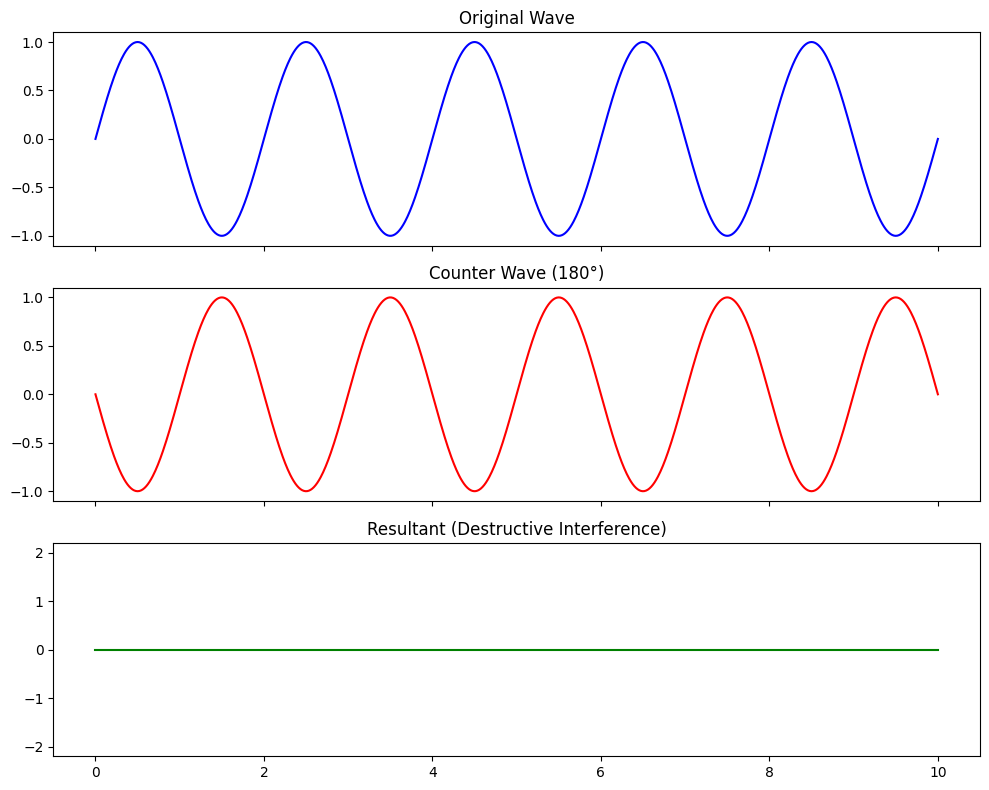

In [1]:
"""
Project 1: Wave Simulator
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1. Wave Parameters
# ---------------------------
amplitude = 1.0          # Amplitude (A)
wavelength = 2.0         # Wavelength (lambda), মিটারে
x = np.linspace(0, 10, 1000)  # x-axis: room-এর দৈর্ঘ্য বরাবর position

k = 2 * np.pi / wavelength    # Wave number (k = 2π/λ)

# ---------------------------
# 2. Original Wave
# y(x) = A * sin(kx)
# ---------------------------
original_wave = amplitude * np.sin(k * x)

# ---------------------------
# 3. Counter Wave (180° phase shift)
# ---------------------------
phase_shift = np.pi
counter_wave = amplitude * np.sin(k * x + phase_shift)

# ---------------------------
# 4. Superposition (যোগফল)
# ---------------------------
resultant_wave = original_wave + counter_wave

# ---------------------------
# 5. Reduction পরিমাপ (dB-তে)
# ---------------------------
original_power = np.mean(original_wave ** 2)
resultant_power = np.mean(resultant_wave ** 2)
reduction_db = 10 * np.log10(original_power / max(resultant_power, 1e-20))
print(f"RF Reduction: {reduction_db:.2f} dB (idealized)")

# ---------------------------
# 6. Plot
# ---------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(x, original_wave, color="blue"); axes[0].set_title("Original Wave")
axes[1].plot(x, counter_wave, color="red"); axes[1].set_title("Counter Wave (180°)")
axes[2].plot(x, resultant_wave, color="green"); axes[2].set_title("Resultant (Destructive Interference)")
axes[2].set_ylim(-2.2, 2.2)
plt.tight_layout()
plt.savefig("project1_output.png", dpi=150)
plt.show()

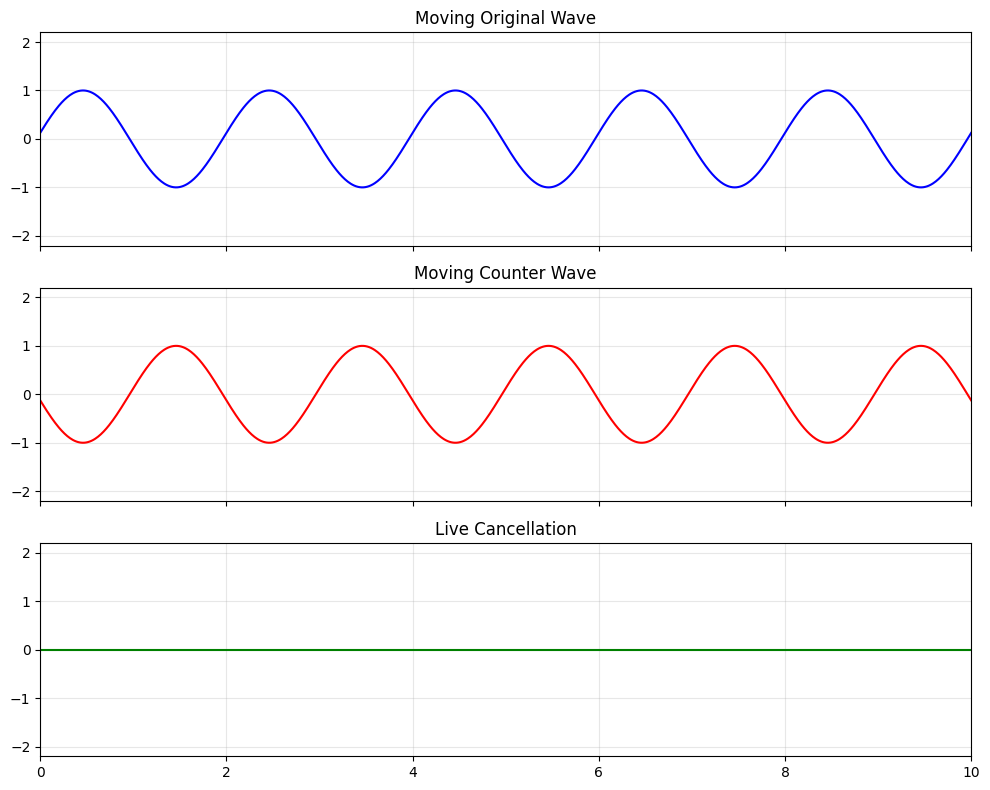

In [2]:
"""
Project 2: Animated Wave Simulator
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ---------------------------
# 1. Parameters
# ---------------------------
amplitude = 1.0
wavelength = 2.0
k = 2 * np.pi / wavelength      # wave number
omega = 2 * np.pi * 1.0         # angular frequency (f = 1 Hz ধরা হলো)
x = np.linspace(0, 10, 1000)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
line1, = axes[0].plot([], [], color="blue")
line2, = axes[1].plot([], [], color="red")
line3, = axes[2].plot([], [], color="green")

for ax, title in zip(axes, ["Moving Original Wave", "Moving Counter Wave", "Live Cancellation"]):
    ax.set_xlim(0, 10)
    ax.set_ylim(-2.2, 2.2)
    ax.set_title(title)
    ax.grid(alpha=0.3)

# ---------------------------
# 2. Frame Update Function
# ---------------------------
def update(frame):
    t = frame * 0.02   # সময় বাড়ছে frame অনুযায়ী

    original_wave = amplitude * np.sin(k * x - omega * t)
    counter_wave  = amplitude * np.sin(k * x - omega * t + np.pi)  # 180° shift, একই গতি
    resultant     = original_wave + counter_wave

    line1.set_data(x, original_wave)
    line2.set_data(x, counter_wave)
    line3.set_data(x, resultant)
    return line1, line2, line3

# ---------------------------
# 3. Animate
# ---------------------------
ani = animation.FuncAnimation(fig, update, frames=200, interval=30, blit=True)
plt.tight_layout()

# GIF হিসেবে সেভ করতে:
ani.save("project2_output.gif", writer="pillow", fps=30)
# অথবা ইন্টারেক্টিভভাবে দেখতে:
# plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # Colab এ দেখার জন্য যুক্ত করা হলো

# -----------------------
# Parameters
# -----------------------
frequency = 5
amplitude = 1

# Time Axis
t = np.linspace(0, 2, 1000)

# Figure
fig, ax = plt.subplots(figsize=(12, 5))

line1, = ax.plot([], [], label="RF Wave", color='blue', linestyle='--')
line2, = ax.plot([], [], label="Counter Wave", color='red', linestyle=':')
line3, = ax.plot([], [], label="Result", color='black', linewidth=3)

ax.set_xlim(0, 2)
ax.set_ylim(-2.5, 2.5)
ax.grid()
ax.legend(loc='upper right')

# -----------------------
def animate(frame):
    phase = frame * 0.1

    wave1 = amplitude * np.sin(
        2 * np.pi * frequency * t - phase
    )

    wave2 = amplitude * np.sin(
        2 * np.pi * frequency * t - phase + np.pi
    )

    result = wave1 + wave2

    line1.set_data(t, wave1)
    line2.set_data(t, wave2)
    line3.set_data(t, result)

    return line1, line2, line3

ani = FuncAnimation(
    fig,
    animate,
    frames=300,
    interval=30,
    blit=True
)

# Colab-এ সাধারণ গ্রাফ আসা বন্ধ করে শুধু অ্যানিমেশন দেখানোর জন্য
plt.close()

# অ্যানিমেশন প্লে করার কমান্ড
HTML(ani.to_jshtml())

Animation size has reached 21005039 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.
